In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [4]:
import os
print("Files in data/raw folder:")
for file in os.listdir('../data/raw/'):
    print(f"   - {file}")

Files in data/raw folder:
   - creditcard.csv.zip
   - Fraud_Data.csv
   - IpAddress_to_Country.csv


In [5]:
import zipfile
import os

#unzip the file
zip_path = '../data/raw/creditcard.csv.zip'
extract_path = '../data/raw/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("File unzipped successfully!")

#verify it's there
print("\nFiles in data/raw folder now:")
for file in os.listdir('../data/raw/'):
    print(f"   - {file}")

File unzipped successfully!

Files in data/raw folder now:
   - creditcard.csv
   - creditcard.csv.zip
   - Fraud_Data.csv
   - IpAddress_to_Country.csv


In [6]:
credit_df = pd.read_csv('../data/raw/creditcard.csv')
print(f"Shape: {credit_df.shape}")
credit_df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
print("Dataset Info:")
credit_df.info()
print("\nMissing values:", credit_df.isnull().sum().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21    

In [8]:
print("CLASS DISTRIBUTION:")
print(credit_df['Class'].value_counts())
print(f"\nFraud percentage: {credit_df['Class'].mean() * 100:.4f}%")
print(f"Legitimate percentage: {(1 - credit_df['Class'].mean()) * 100:.4f}%")

CLASS DISTRIBUTION:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%
Legitimate percentage: 99.8273%


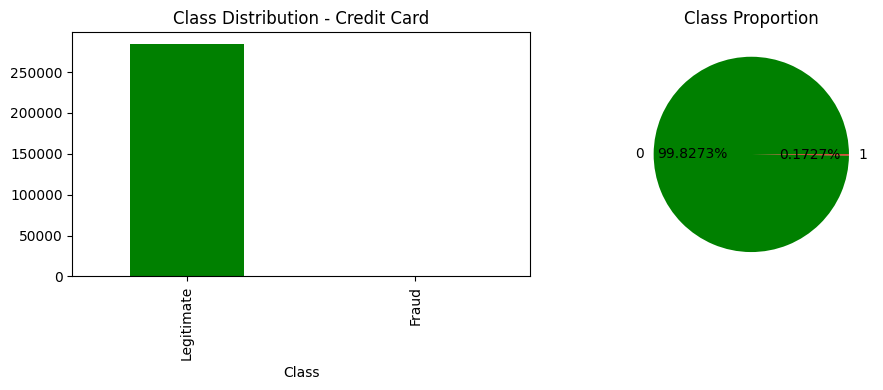

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
credit_df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution - Credit Card')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
credit_df['Class'].value_counts().plot(kind='pie', autopct='%1.4f%%', ax=axes[1], colors=['green', 'red'])
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.savefig('../reports/creditcard_imbalance.png', dpi=100)
plt.show()

In [10]:
print("Amount Statistics:")
print(credit_df['Amount'].describe())
print("\nAmount by Class:")
print(credit_df.groupby('Class')['Amount'].describe())

Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Amount by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


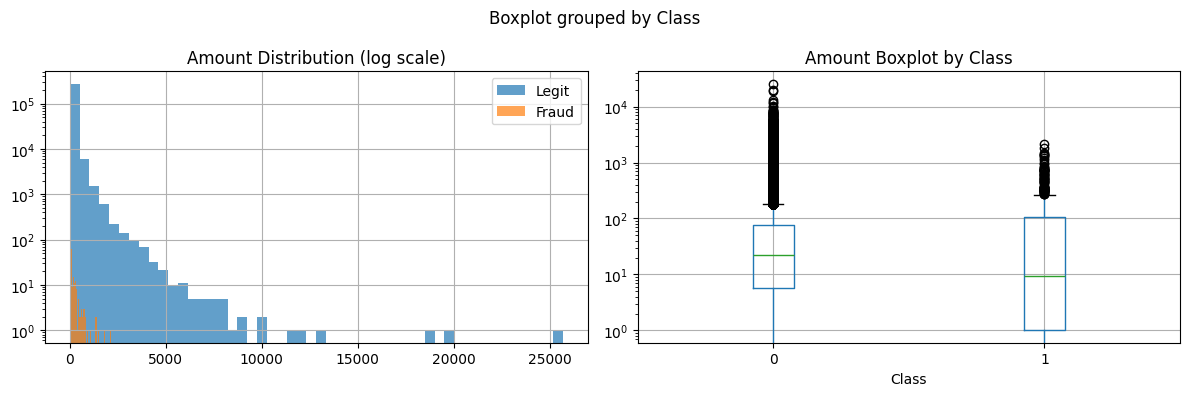

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
credit_df[credit_df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.7, label='Legit', ax=axes[0])
credit_df[credit_df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.7, label='Fraud', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Amount Distribution (log scale)')
axes[0].legend()
credit_df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount Boxplot by Class')
axes[1].set_yscale('log')
plt.tight_layout()
plt.savefig('../reports/creditcard_amount.png', dpi=100)
plt.show()

Time Statistics:
Time range: 0.0 to 172792.0 seconds
Time in hours: 48.0 hours


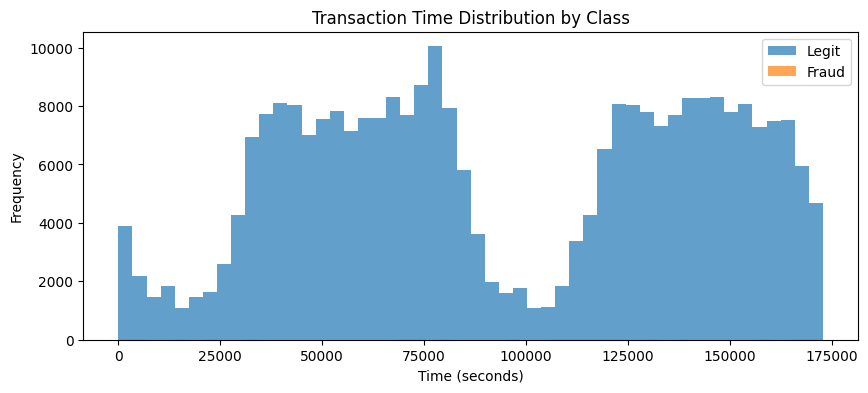

In [12]:
print("Time Statistics:")
print(f"Time range: {credit_df['Time'].min()} to {credit_df['Time'].max()} seconds")
print(f"Time in hours: {credit_df['Time'].max()/3600:.1f} hours")
plt.figure(figsize=(10, 4))
plt.hist(credit_df[credit_df['Class'] == 0]['Time'], bins=50, alpha=0.7, label='Legit')
plt.hist(credit_df[credit_df['Class'] == 1]['Time'], bins=50, alpha=0.7, label='Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title('Transaction Time Distribution by Class')
plt.legend()
plt.savefig('../reports/creditcard_time.png', dpi=100)
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
credit_df['Amount_scaled'] = scaler.fit_transform(credit_df[['Amount']])
credit_df.to_csv('../data/processed/creditcard_processed.csv', index=False)
print(" Saved: ../data/processed/creditcard_processed.csv")
print(f"Final shape: {credit_df.shape}")

 Saved: ../data/processed/creditcard_processed.csv
Final shape: (284807, 32)


In [14]:
import os
print("Files in reports folder:")
for f in os.listdir('../reports/'):
    print(f"   - {f}")

Files in reports folder:
   - creditcard_amount.png
   - creditcard_imbalance.png
   - creditcard_time.png
   - shap_bar_plot.png
   - shap_summary_plot.png
